# 06 — Fossil Climate Detectives

**How do we know it used to be warmer — or colder — somewhere on Earth?**

**Your mission:** slide through six real rock-clue ages and go clue-hunting
— which climate icons show up, where, and how many of each?

Rocks and fossils can be climate clues! A layer of **coal** used to be a
soggy swamp forest. A fossil **crocodile** could only have lived somewhere
warm. A scratched, jumbled rock called a **tillite** was dropped by a
melting glacier. Scientists have collected thousands of these climate
clues from rocks all over the world, and in this notebook you'll plot real
ones on a map — reconstructed to where the land actually was when each
clue was formed.

**Where this data comes from**: Boucot, Xu & Scotese (2013) catalogued
these climate-sensitive rocks and fossils from the published geological
literature. We group their original 15 rock/fossil categories into a
handful of kid-friendly climate types, each with its own icon.

**A note on honesty**: this dataset doesn't have a category specifically
for coral reefs, so there's no coral icon here — the crocodile icon
(Boucot's "warm temperate" group, which also includes palms and mangroves)
is the closest real match to "warm and wet." And real data is patchy, not
like a video game: at some ages, a climate type might have zero clues
recorded simply because nobody's found and published one yet, not because
that climate didn't exist. The real data also has a sixth, "cold"
category — ice-age clues like tillites and dropstones — but at these
particular ages there are only ever a handful of them among well over a
thousand points, and this notebook's map colours land by *height*, not by
ice cover, so a single snowflake floating on ordinary-looking green land
was more likely to confuse than to teach. We've left it out of the map and
legend below; it's still there in the raw data if you go looking (see
"Try this next!" at the bottom).

*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*


## Before you start

Run the cell below first.

In [1]:
# Housekeeping — checks the data files this notebook needs are present.
# If this is the first time anyone has opened Deep Time Explorers, a grown-up
# needs to run export_data.py once (see the suite README) before this will work.
from pathlib import Path
import os as _os

if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

_required = [
    "data/fossils_through_time.csv",
    "data/basemap_410Ma.png",
    "data/basemap_330Ma.png",
    "data/basemap_240Ma.png",
    "data/basemap_155Ma.png",
    "data/basemap_80Ma.png",
    "data/basemap_15Ma.png",
    "data/basemap_0Ma.png",
]
_missing = [f for f in _required if not Path(f).exists()]
if _missing:
    raise FileNotFoundError(
        "Missing data file(s): " + ", ".join(_missing) +
        "\n\nAsk a grown-up to run export_data.py once from the "
        "deep-time-explorers folder — see README.md. "
    )
print("All data files found — ready to go!")


All data files found — ready to go!


In [2]:
# The only packages this notebook needs. In a normal Jupyter/conda install
# these are already there — nothing to do. In the browser-based JupyterLite
# version, `ipywidgets` isn't preinstalled, so the two lines below ask
# Pyodide's package installer to fetch it once, the first time you run this
# cell; they do nothing outside the browser.
import sys
if "pyodide" in sys.modules:
    import piplite
    await piplite.install("ipywidgets")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown


In [3]:
# --- Robinson world-map helpers -------------------------------------------
# These four numbers describe the exact shape of a full-globe "Robinson"
# map projection (the curved world-map style used below). They're always
# the same no matter what age we're looking at, so we only need to write
# them once. export_data.py used the exact same numbers when it made the
# background pictures, so everything lines up perfectly.
ROBINSON_EXTENT = (-20464646.889276125, 17966614.874622703, -10991340.864475066, 10145853.105669294)

def show_basemap(ax, age_ma):
    """Draw the real paleo-elevation world map for a given age. Green/tan
    shows low land, browns and white show mountains — the SAME kind of
    colouring you'd see on a real physical-geography map today."""
    img = plt.imread(f"data/basemap_{int(age_ma)}Ma.png")
    ax.imshow(img, extent=ROBINSON_EXTENT, origin="upper")
    ax.set_xlim(ROBINSON_EXTENT[0], ROBINSON_EXTENT[1])
    ax.set_ylim(ROBINSON_EXTENT[2], ROBINSON_EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([])
    ax.axis("off")


In [4]:
# --- Climate-clue icons ----------------------------------------------------
# Hand-drawn with plain matplotlib shapes (triangles, circles, wedges) --
# no picture files needed, and they'll look the same on every computer.
# Feel free to redesign any of these — that's part of the fun!

def _stick(ax, p0, p1, halfwidth, color, zorder=6):
    """A thin filled rectangle between two points -- used instead of a
    stroked line so the icons stay crisp at any zoom level."""
    (x0, y0), (x1, y1) = p0, p1
    dx, dy = x1 - x0, y1 - y0
    length = np.hypot(dx, dy)
    if length < 1e-9:
        return
    ux, uy = dx / length, dy / length
    px, py = -uy * halfwidth, ux * halfwidth
    ax.add_patch(mpatches.Polygon([
        (x0 + px, y0 + py), (x1 + px, y1 + py), (x1 - px, y1 - py), (x0 - px, y0 - py)
    ], closed=True, color=color, zorder=zorder))


# Every draw_* icon below takes a `z0` (base zorder) parameter -- each icon
# is built from 2-3 layers that must stay in a fixed relative order (e.g. a
# tree trunk behind its own leaves), so z0, z0+1, z0+2 preserve that order
# wherever the icon is drawn. Used both for the real data icons on the map
# (z0=5, same as before) AND for the miniature versions of the same icons
# drawn inside draw_legend() below (a much higher z0, so they sit cleanly on
# top of the legend's background box instead of being hidden behind it).

def draw_snowflake(ax, x, y, s=1.0, color="#8ecbe8", z0=5):
    """cold -- tillites, dropstones, glendonites, ice crystals"""
    for angle in range(0, 360, 60):
        rad = np.deg2rad(angle)
        dx, dy = np.cos(rad) * s, np.sin(rad) * s
        _stick(ax, (x, y), (x + dx, y + dy), 0.05 * s, color, zorder=z0 + 1)
        for t in (0.5, 0.8):
            bx, by = x + dx * t, y + dy * t
            for sign in (1, -1):
                brad = rad + sign * np.deg2rad(35)
                _stick(ax, (bx, by), (bx + np.cos(brad) * 0.3 * s, by + np.sin(brad) * 0.3 * s),
                       0.035 * s, color, zorder=z0 + 1)
    ax.add_patch(mpatches.Circle((x, y), 0.12 * s, color=color, zorder=z0 + 1))


def draw_conifer(ax, x, y, s=1.0, color="#1e5c2e", trunk="#5a3a22", z0=5):
    """wet_humid -- coals (ancient swamp forests)"""
    ax.add_patch(mpatches.Rectangle((x - 0.08 * s, y - 0.9 * s), 0.16 * s, 0.4 * s, color=trunk, zorder=z0))
    for w, yc in [(0.9, -0.55), (0.75, -0.15), (0.55, 0.25)]:
        ax.add_patch(mpatches.Polygon(
            [(x - w * s / 2, y + yc * s), (x + w * s / 2, y + yc * s), (x, y + (yc + 0.45) * s)],
            color=color, zorder=z0 + 1))


def draw_palm(ax, x, y, s=1.0, color="#2e8b3d", trunk="#8a6a3a", z0=5):
    """warm_humid -- bauxites, laterites, kaolinites, oolitic ironstones
    (rock left behind by hot, heavy-rainfall weathering -- the kind of
    weather tropical rainforests need)"""
    trunk_pts = [(x - 0.10 * s, y - 0.9 * s), (x - 0.02 * s, y - 0.55 * s),
                 (x + 0.06 * s, y - 0.2 * s), (x + 0.02 * s, y + 0.05 * s)]
    for p0, p1 in zip(trunk_pts[:-1], trunk_pts[1:]):
        _stick(ax, p0, p1, 0.06 * s, trunk, zorder=z0)
    crown = (x + 0.02 * s, y + 0.05 * s)
    for angle_deg in (150, 115, 80, 45, 15, 200):
        rad = np.deg2rad(angle_deg)
        tip = (crown[0] + np.cos(rad) * 0.6 * s, crown[1] + np.sin(rad) * 0.42 * s + 0.05 * s)
        perp = np.deg2rad(angle_deg + 90)
        w = 0.09 * s
        p1 = (crown[0] + np.cos(perp) * w, crown[1] + np.sin(perp) * w)
        p2 = (crown[0] - np.cos(perp) * w, crown[1] - np.sin(perp) * w)
        ax.add_patch(mpatches.Polygon([p1, tip, p2], color=color, zorder=z0 + 1))
    ax.add_patch(mpatches.Circle(crown, 0.06 * s, color=trunk, zorder=z0 + 2))


def draw_crocodile(ax, x, y, s=1.0, color="#4a7c3a", dark="#2f5423", z0=5):
    """warm_temp -- palms, mangroves, CROCODILIANS, lungfish burrows found
    much closer to the poles than crocodiles live today -- a big clue
    that it used to be much warmer there.

    Revision note (v1.5): redesigned after a report that this icon read as
    "a horizontal tree", not a crocodile -- fair complaint, looking back:
    a plain green oval with two thin triangle tapers had no feature that
    actually says "reptile." The eye dot was also placed on the TAIL end
    by mistake instead of the head end, which didn't help. Added a jagged
    back ridge (crocodiles' single most recognisable silhouette cue) and a
    visible jaw line on the snout, and moved the eye to the correct (head)
    end."""
    for lx in (-0.35, 0.25):
        for sign in (1, -1):
            ax.add_patch(mpatches.Ellipse((x + lx * s, y - 0.2 * s * sign), 0.14 * s, 0.07 * s,
                                           angle=20 * sign, color=color, zorder=z0))
    ax.add_patch(mpatches.Ellipse((x, y), 1.15 * s, 0.30 * s, color=color, zorder=z0 + 1))
    ax.add_patch(mpatches.Polygon([(x - 0.55 * s, y + 0.08 * s), (x - 1.0 * s, y + 0.01 * s),
                                    (x - 1.0 * s, y - 0.05 * s), (x - 0.55 * s, y - 0.08 * s)],
                                   color=color, zorder=z0 + 1))
    ax.add_patch(mpatches.Polygon([(x + 0.55 * s, y + 0.12 * s), (x + 1.05 * s, y), (x + 0.55 * s, y - 0.12 * s)],
                                   color=color, zorder=z0 + 1))
    for bx in (-0.35, -0.15, 0.05, 0.25):
        ax.add_patch(mpatches.Polygon([
            (x + (bx - 0.08) * s, y + 0.14 * s), (x + bx * s, y + 0.30 * s), (x + (bx + 0.08) * s, y + 0.14 * s),
        ], color=dark, zorder=z0 + 2))
    _stick(ax, (x + 0.55 * s, y), (x + 1.0 * s, y), 0.012 * s, dark, zorder=z0 + 3)
    ax.add_patch(mpatches.Circle((x + 0.62 * s, y + 0.10 * s), 0.035 * s, color="black", zorder=z0 + 4))


def draw_desert(ax, x, y, s=1.0, dune_color="#d9b36c", sun_color="#f2a51a", z0=5):
    """arid -- evaporites, calcretes"""
    ax.add_patch(mpatches.Circle((x + 0.35 * s, y + 0.35 * s), 0.18 * s, color=sun_color, zorder=z0 + 1))
    ax.add_patch(mpatches.Wedge((x, y - 0.3 * s), 0.7 * s, 0, 180, color=dune_color, zorder=z0 + 1))
    ax.add_patch(mpatches.Wedge((x + 0.35 * s, y - 0.35 * s), 0.45 * s, 0, 180, color="#c9a15c", zorder=z0 + 2))


CLIMATE_ICON = {
    "wet_humid": draw_conifer,
    "warm_humid": draw_palm,
    "warm_temp": draw_crocodile,
    "arid": draw_desert,
}
CLIMATE_LABEL = {
    # Short names for the on-map legend -- kept short on purpose so 4 (or,
    # if you add "cold" back into CLIMATE_ICON, 5) columns fit comfortably
    # in one row under the map without any label overlapping its neighbour.
    "cold": "Cold",  # not in CLIMATE_ICON -- see the "Try this next!" idea
    # at the bottom of the notebook, which invites kids to add
    # "cold": draw_snowflake back into CLIMATE_ICON themselves. Kept here so
    # draw_legend() already has a label ready if they do.
    "wet_humid": "Wet & humid",
    "warm_humid": "Warm & rainy",
    "warm_temp": "Warm temperate",
    "arid": "Dry / desert",
}


def draw_legend(ax_legend, sub):
    """A hand-built legend that shows each climate bin's REAL icon next to
    its label and count -- not matplotlib's usual auto-legend. A plain
    ax.legend() only knows how to draw its own line/patch swatches, so it
    can't show one of these hand-drawn multi-shape icons as a key; asking
    it to anyway (an earlier version passed `color="none"` patches, hoping
    for text-only entries) just produced blank, invisible swatches next to
    the labels -- exactly the "empty legend" bug reported. This instead
    calls the SAME draw_conifer/draw_palm/etc functions used for the real
    map data, directly on a small dedicated legend axes.

    Revision note (v1.3): this used to draw straight onto the map's own
    axes, positioned with an axes-fraction-to-data-coordinate conversion so
    it would sit in a corner "on top of" the globe -- which, on a full
    global map, meant it covered a big chunk of real ocean/continent no
    matter which corner it went in. Moved to its own axes, placed by
    `show_fossils` in a second, short row *underneath* the globe instead of
    overlapping it, per the user's report. Because this axes has nothing
    else on it, its coordinates are set to a plain 0-1 square (`set_xlim`/
    `set_ylim`), so icon positions below are just simple fractions across
    the strip -- no transData/transAxes conversion needed any more."""
    ax_legend.axis("off")
    # This strip is much wider than it is tall, but the icon-drawing
    # functions assume equal x/y scaling (same as they get on the actual
    # map, where Robinson x/y really are equal-aspect) -- a naive 0-1 x 0-1
    # square here would squash every icon sideways. Force a layout pass,
    # read back this axes' REAL on-screen box, and pick an x-range that
    # matches its true pixel aspect ratio so "s" means the same physical
    # size in both directions.
    ax_legend.figure.canvas.draw()
    bbox = ax_legend.get_window_extent()
    aspect = bbox.width / bbox.height
    ax_legend.set_xlim(0, aspect)
    ax_legend.set_ylim(0, 1)
    n = len(CLIMATE_ICON)
    for i, (climate_bin, draw_fn) in enumerate(CLIMATE_ICON.items()):
        cx = aspect * (i + 0.5) / n
        draw_fn(ax_legend, cx, 0.6, s=0.16)
        count = int((sub["bin"] == climate_bin).sum())
        ax_legend.text(cx, 0.12, f"{CLIMATE_LABEL[climate_bin]}\n(×{count})",
                        ha="center", va="center", fontsize=8.5)


In [5]:
fossils = pd.read_csv("data/fossils_through_time.csv")
FOSSIL_AGES = [410, 330, 240, 155, 80, 15, 0]
AGE_LABEL = {
    410: "410 Ma — Devonian: the first forests",
    330: "330 Ma — Carboniferous: the great coal swamps",
    240: "240 Ma — Triassic: a hot world after Earth's worst extinction",
    155: "155 Ma — Jurassic: age of the dinosaurs",
    80:  "80 Ma — Cretaceous: the last age of the dinosaurs",
    15:  "15 Ma — Miocene: a cooling, more familiar world",
    0:   "Today",
}
print(f"{len(fossils)} climate clues loaded across {len(FOSSIL_AGES) - 1} rock-clue ages, plus today")
fossils["bin"].value_counts()


1665 climate clues loaded across 6 rock-clue ages, plus today


bin
wet_humid     804
arid          612
warm_humid    210
cold           30
warm_temp       9
Name: count, dtype: int64

## Pick a time and go looking for clues

Move the slider to travel between six real rock-clue ages, all the way to
today. Watch which icons appear, where, and how many of each.

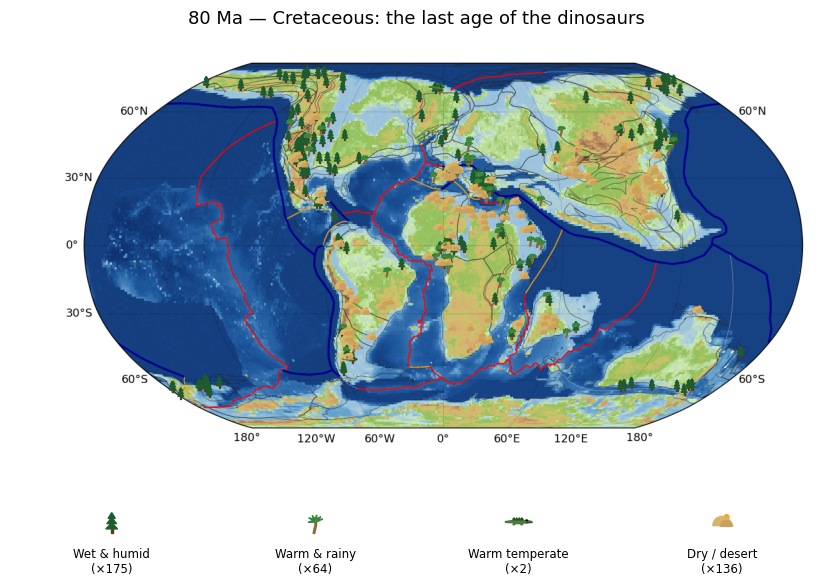

interactive(children=(SelectionSlider(description='Time:', options=(410, 330, 240, 155, 80, 15, 0), value=410)…

In [6]:
def show_fossils(age_ma):
    # Two rows sharing one figure -- a big one for the map, a short one
    # underneath just for the legend, so the legend never covers up part
    # of the actual map data (an earlier version drew it in a corner of
    # the map itself, which on a full globe always hid real ocean/land).
    fig, (ax, ax_legend) = plt.subplots(
        2, 1, figsize=(10.5, 7), gridspec_kw={"height_ratios": [6, 1.1], "hspace": 0.04})
    show_basemap(ax, age_ma)
    icon_size = ROBINSON_EXTENT[1] * 0.018
    sub = fossils[fossils.age_ma == age_ma]
    if age_ma == 0:
        # There's no Boucot rock-clue data for today, on purpose -- these
        # are all CLUES for figuring out a climate nobody could observe
        # directly. Today we don't need clues, we can just look outside!
        ax.set_title(AGE_LABEL[age_ma], fontsize=13)
        ax.text(0.5, 0.06, "No rock clues needed for today — we can just look outside!",
                transform=ax.transAxes, ha="center", fontsize=10,
                bbox=dict(facecolor="white", edgecolor="0.4", alpha=0.9, boxstyle="round,pad=0.4"))
        ax_legend.axis("off")
        plt.show()
        return
    for climate_bin, draw_fn in CLIMATE_ICON.items():
        pts = sub[sub.bin == climate_bin]
        for _, row in pts.iterrows():
            draw_fn(ax, row.robinson_x, row.robinson_y, s=icon_size)
    draw_legend(ax_legend, sub)
    ax.set_title(AGE_LABEL[age_ma], fontsize=13)
    plt.show()

# One age shown as a plain static picture -- shows up even where the
# slider below can't run (like GitHub's preview). 80 Ma has a good mix of
# climate-clue icons on the map; every other age is one slider-move away.
show_fossils(80)
interact(show_fossils, age_ma=SelectionSlider(options=FOSSIL_AGES, description="Time:"));


## What do you notice?

- Do the crocodile icons (warm temperate) ever show up surprisingly close
  to a pole? That's a real, famous clue — it means that spot used to be
  much warmer than it is today, either because the *climate* was warmer,
  or because *the land itself* has since drifted toward the pole (or both!).
- At 330 Ma, one climate type covers huge stretches of every continent —
  which one, and why do you think that age got nicknamed the "Coal Age"?

## Try this next!

- Count the icons of each type at two different ages with `fossils[fossils.age_ma == 155]["bin"].value_counts()` — which climate type grew, and which shrank?
- There's a fifth icon, `draw_snowflake`, already defined above for the "cold" (ice-age) climate type — it's just not switched on. Try adding `"cold": draw_snowflake` into `CLIMATE_ICON` near the top and re-run the map. Which ages get a snowflake, and how many?
- Compare this notebook's map to Notebook 1's — can you match up a continent's shape at the same age?

---
*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*
